In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
DATA_PATH = "../data/processed/final_gene_features.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")

Dataset loaded successfully


In [6]:
print("Dataset shape:", df.shape)

rows, cols = df.shape

print("Number of genes:", rows)
print("Number of features:", cols)

Dataset shape: (23050, 49)
Number of genes: 23050
Number of features: 49


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GeneSymbol                 23050 non-null  object 
 1   total_variants             23050 non-null  int64  
 2   pathogenic_variants        23050 non-null  int64  
 3   benign_variants            23050 non-null  int64  
 4   variant_type_diversity     23050 non-null  int64  
 5   chromosome_diversity       23050 non-null  int64  
 6   unique_variant_count       23050 non-null  int64  
 7   description                23050 non-null  object 
 8   rare_variants              23050 non-null  int64  
 9   gene_degree                23050 non-null  float64
 10  clustering_coefficient     23050 non-null  float64
 11  pagerank                   23050 non-null  float64
 12  betweenness_centrality     23050 non-null  float64
 13  node2vec_0                 23050 non-null  flo

Missing Value Check

In [8]:
missing = df.isnull().sum()

print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Series([], dtype: int64)


In [9]:
duplicates = df["GeneSymbol"].duplicated().sum()

print("Duplicate genes:", duplicates)

Duplicate genes: 0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_variants,23050.0,69.054273,308.472086,1.000000,1.000000,4.000000e+00,18.000000,2.181900e+04
pathogenic_variants,23050.0,8.326898,72.156233,0.000000,0.000000,0.000000e+00,1.000000,4.901000e+03
benign_variants,23050.0,9.179046,28.113191,0.000000,0.000000,1.000000e+00,5.000000,9.460000e+02
variant_type_diversity,23050.0,1.837874,1.580352,1.000000,1.000000,1.000000e+00,2.000000,9.000000e+00
chromosome_diversity,23050.0,1.039783,0.620786,1.000000,1.000000,1.000000e+00,1.000000,2.400000e+01
unique_variant_count,23050.0,69.033666,308.452311,1.000000,1.000000,4.000000e+00,18.000000,2.181900e+04
rare_variants,23050.0,59.875228,288.040109,0.000000,1.000000,3.000000e+00,13.000000,2.134300e+04
gene_degree,23050.0,17.934447,37.805128,0.000000,0.000000,3.000000e+00,20.000000,7.610000e+02
clustering_coefficient,23050.0,0.228187,0.284094,0.000000,0.000000,1.108107e-01,0.391126,1.000000e+00
pagerank,23050.0,0.000039,0.000058,0.000000,0.000000,2.054316e-05,0.000056,1.634044e-03


In [11]:
class_counts = df["label"].value_counts()

print("Class distribution:")
print(class_counts)

Class distribution:
label
0    14914
1     8136
Name: count, dtype: int64


In [13]:
majority = class_counts.max()
minority = class_counts.min()

imbalance_ratio = majority / minority

print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 1.8330875122910522


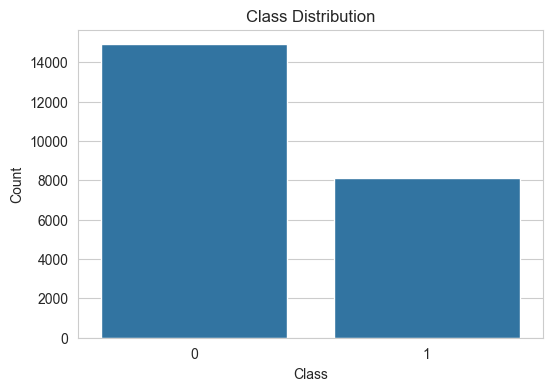

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["label"])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

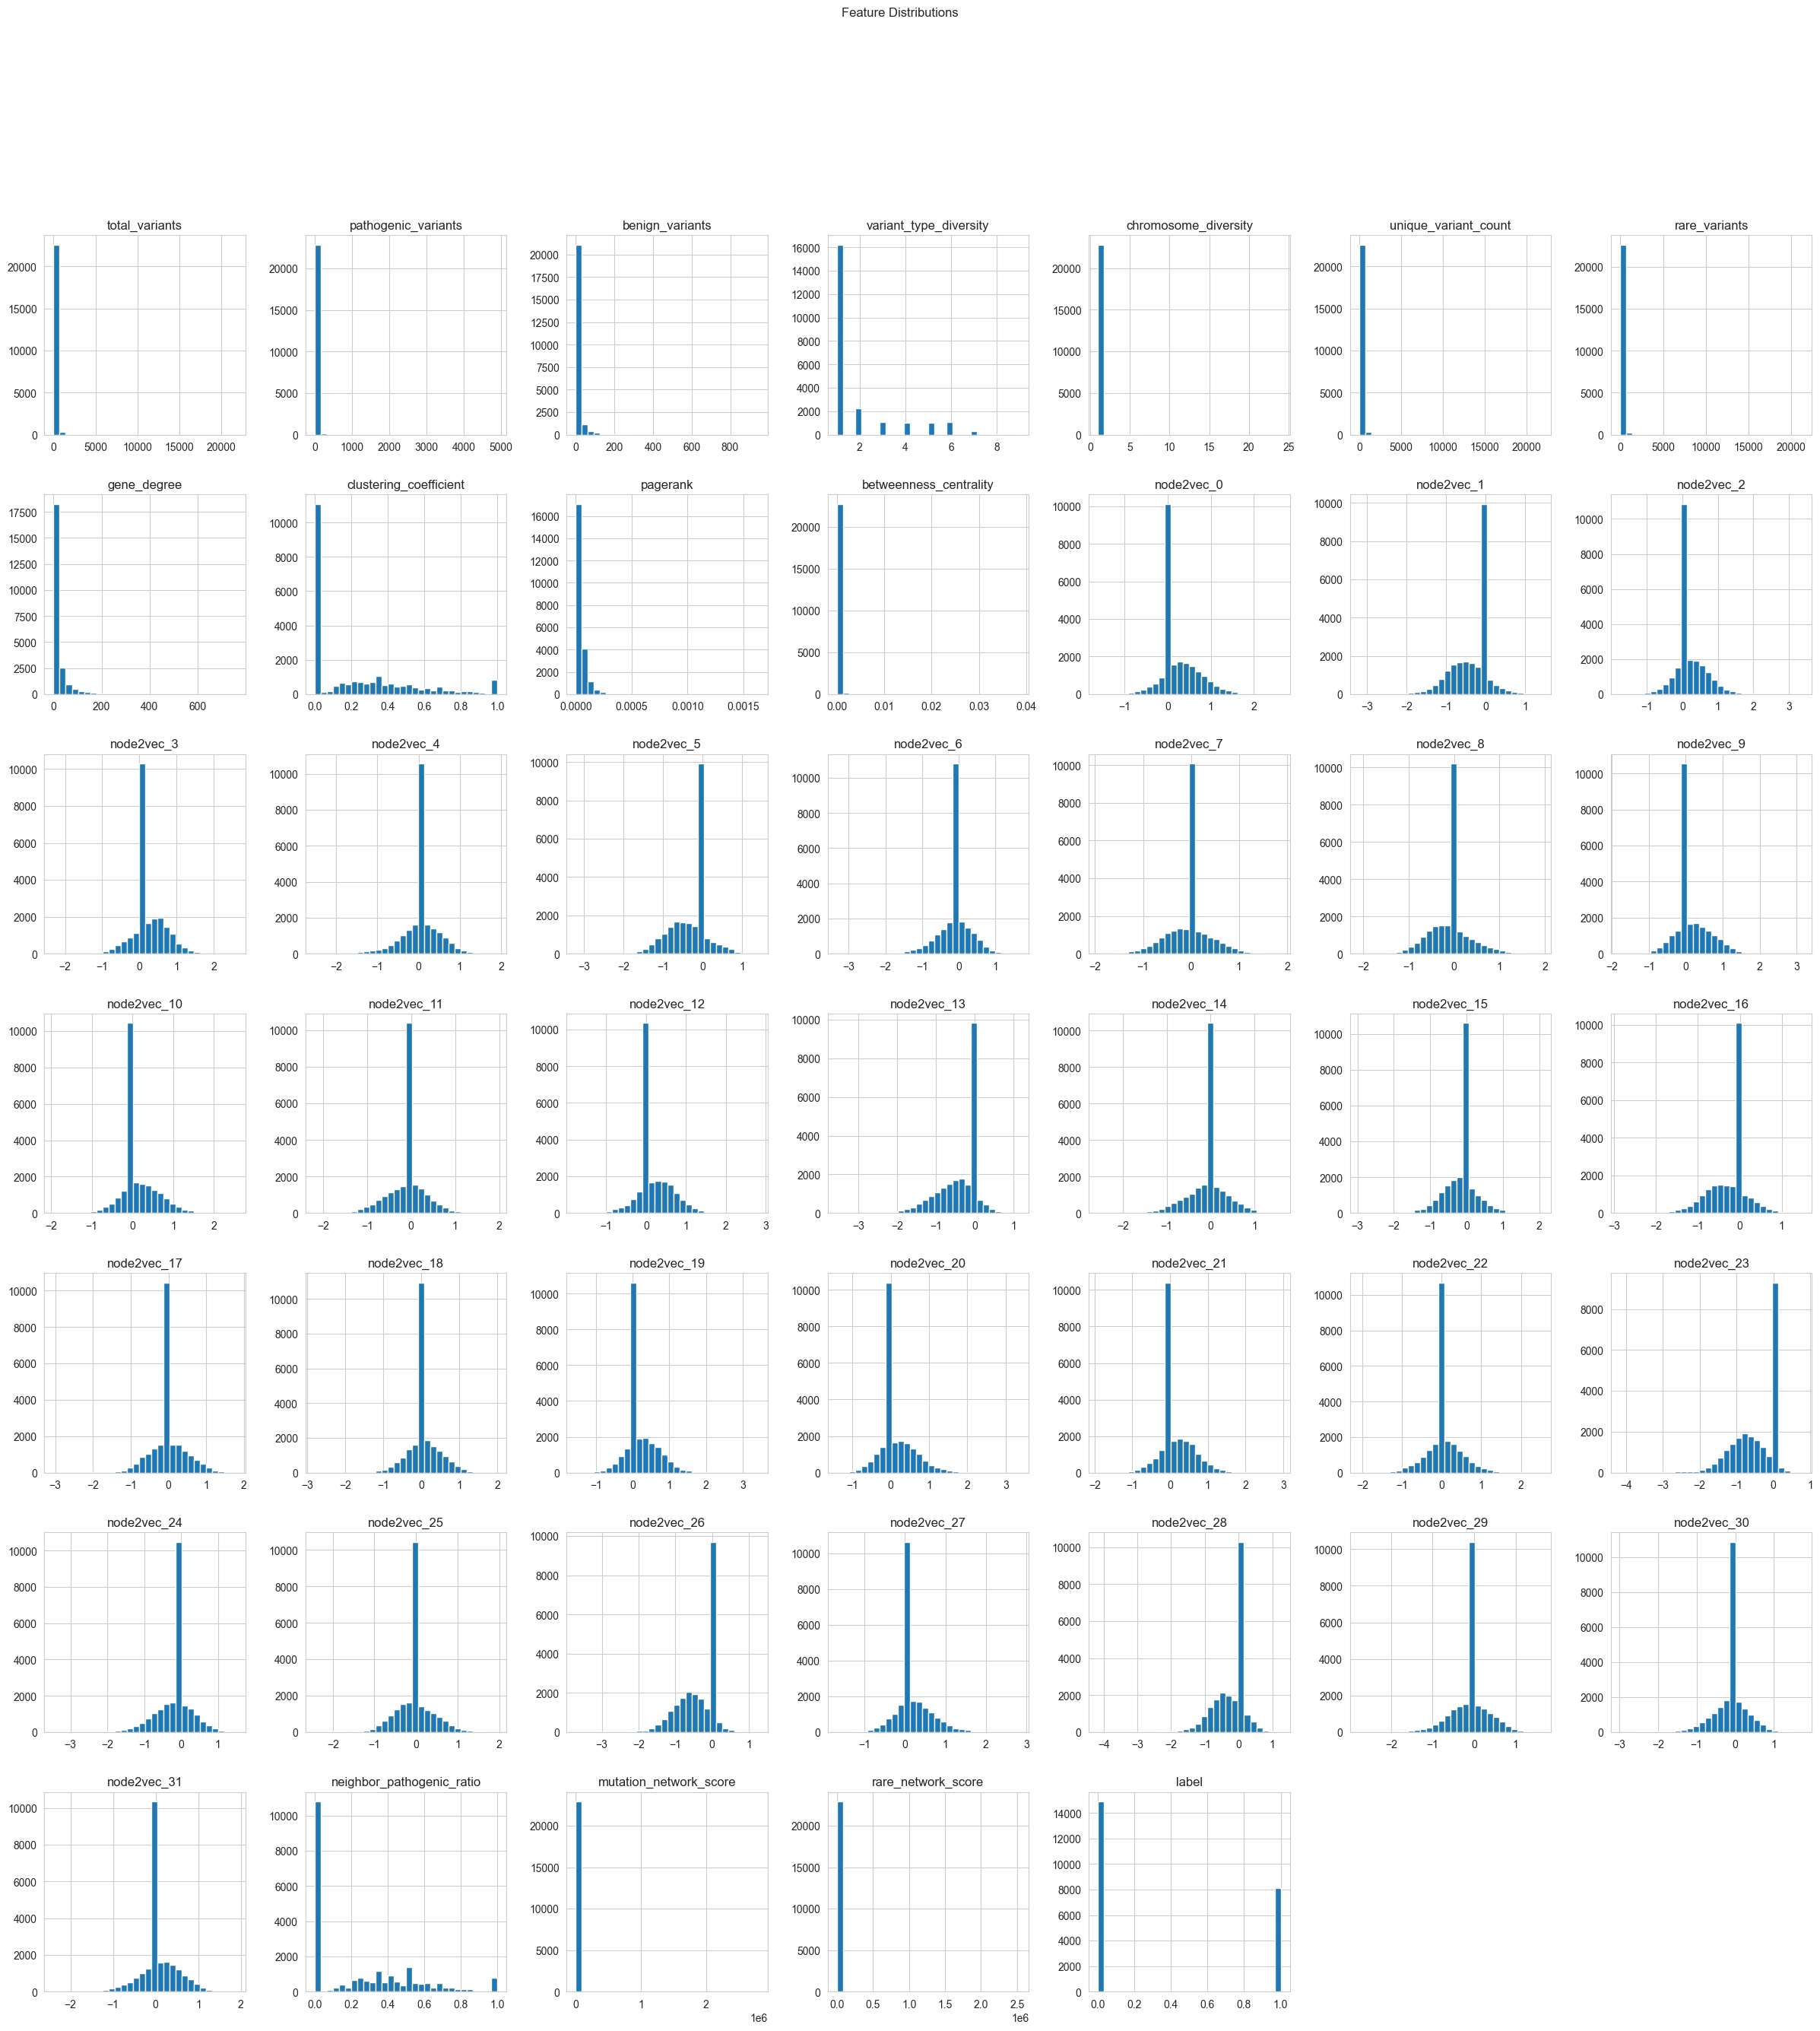

In [24]:
df.hist(
    figsize=(30,30),
    bins=30
)

plt.suptitle("Feature Distributions")
plt.show()

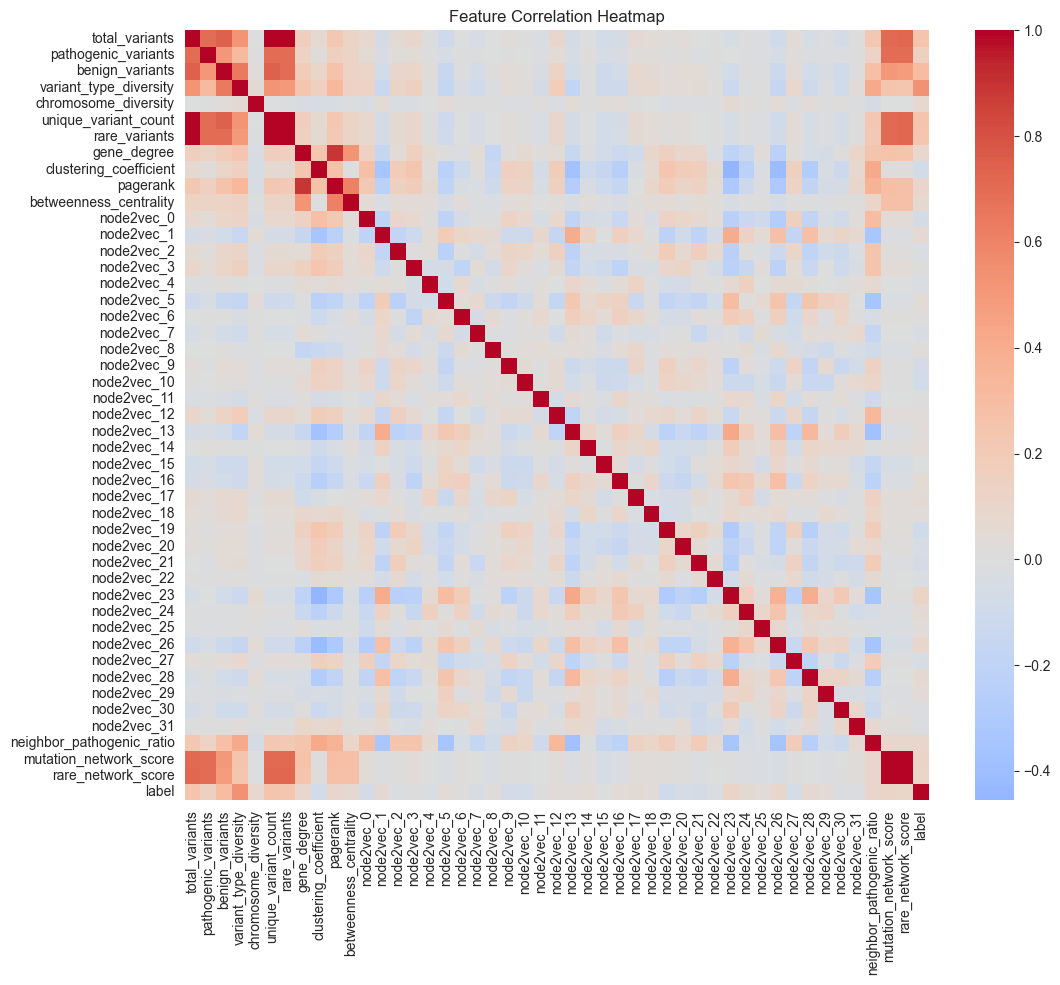

In [16]:
plt.figure(figsize=(12,10))

corr = df.drop(columns=["GeneSymbol","description"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
node2vec_cols = [c for c in df.columns if "node2vec" in c]

print("Number of Node2Vec features:", len(node2vec_cols))

df[node2vec_cols].describe().T

Number of Node2Vec features: 32


,count,mean,std,min,25%,50%,75%,max
node2vec_0,23050.0,0.237400,0.429079,-1.620966,0.000000,0.000000,0.483049,2.627102
node2vec_1,23050.0,-0.321464,0.487247,-3.198901,-0.644818,-0.077264,0.000000,1.426026
node2vec_2,23050.0,0.177532,0.412339,-1.743091,0.000000,0.000000,0.389749,3.393813
node2vec_3,23050.0,0.191777,0.434182,-2.309430,0.000000,0.000000,0.463535,2.604174
node2vec_4,23050.0,0.026789,0.420052,-2.521577,-0.045035,0.000000,0.184841,1.911085
node2vec_5,23050.0,-0.283135,0.480547,-3.213019,-0.605241,0.000000,0.000000,1.414483
node2vec_6,23050.0,-0.074194,0.413766,-3.324119,-0.207668,0.000000,0.020466,1.662564
node2vec_7,23050.0,-0.034296,0.418791,-1.936968,-0.202092,0.000000,0.061892,1.866513
node2vec_8,23050.0,-0.069128,0.405164,-2.092138,-0.273371,0.000000,0.000000,1.932677
node2vec_9,23050.0,0.147575,0.428389,-1.773238,0.000000,0.000000,0.350427,3.167219


In [18]:
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print("Dataset memory size:", round(memory_usage,2), "MB")

Dataset memory size: 11.62 MB


In [19]:
mutation_features = [
    "total_variants",
    "benign_variants",
    "rare_variants"
]

graph_features = [
    "gene_degree",
    "clustering_coefficient",
    "pagerank",
    "betweenness_centrality"
]

node2vec_features = [c for c in df.columns if "node2vec" in c]

print("Mutation features:", len(mutation_features))
print("Graph features:", len(graph_features))
print("Node2Vec features:", len(node2vec_features))

Mutation features: 3
Graph features: 4
Node2Vec features: 32


Pathogenic vs Benign Variant Distribution

In [20]:
import umap

node_embeddings = df[node2vec_cols]

umap_model = umap.UMAP()

embedding = umap_model.fit_transform(node_embeddings)

c:\mutation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


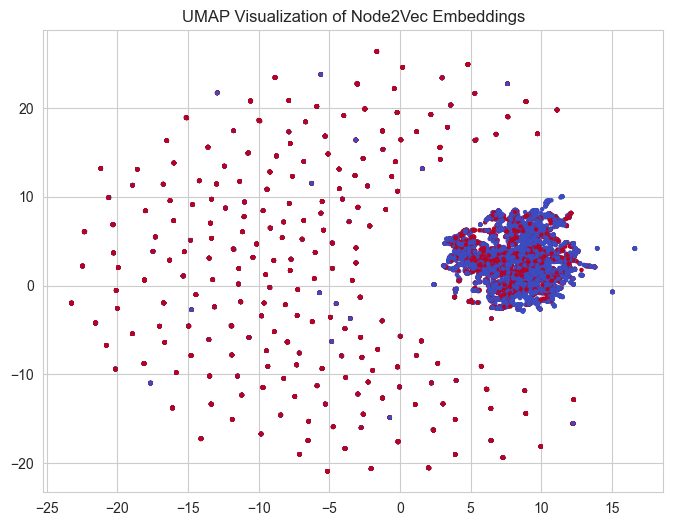

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=df["label"],
    cmap="coolwarm",
    s=5
)

plt.title("UMAP Visualization of Node2Vec Embeddings")

plt.show()